In [209]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler




In [210]:
folder_path = "/content/drive/MyDrive/data_kaggle/alzheimers_disease_data"

x = np.load(f"{folder_path}/X.npy")
y = np.load(f"{folder_path}/y.npy")

In [211]:
print(x.shape, y.shape)
print(np.unique(y, return_counts=True))

(2149, 35) (2149,)
(array([0, 1]), array([1389,  760]))


In [212]:
features= ['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness']

DT Kfold

In [216]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn import tree


In [217]:
skf=StratifiedKFold(n_splits=10,shuffle=True,random_state=0)
skf_split=skf.split(x,y)
acc_train=[]
acc_test=[]
p=[]
f1=[]
r=[]
cm=[]

In [218]:
for i,(train_index,test_index) in enumerate(skf_split):
  print(f'fold_{i+1}')
  x_train,x_test=x[train_index],x[test_index]
  y_train,y_test=y[train_index],y[test_index]
  print("train",np.unique(y_train,return_counts=True))
  print("test",np.unique(y_test,return_counts=True))


  clf_DT = tree.DecisionTreeClassifier(random_state=45)

  param_grid= {'criterion': ['gini', 'entropy'],
               'min_samples_split': [2, 5],
               'min_samples_leaf': [2, 4]}


  grid_cv=GridSearchCV(estimator=clf_DT, param_grid=param_grid,scoring='accuracy',cv=10,verbose=0,refit=True)
  grid_cv.fit(x_train,y_train)

  gr_best=grid_cv.best_params_
  print("--------------------------------")
  print(gr_best)

  clf_DT=tree.DecisionTreeClassifier(criterion=gr_best['criterion'],
                                    min_samples_split=gr_best['min_samples_split'],
                                     min_samples_leaf=gr_best['min_samples_leaf'])

  clf_DT_fit=clf_DT.fit(x_train,y_train)

  y_pred_test=clf_DT_fit.predict(x_test)
  y_pred_train=clf_DT_fit.predict(x_train)
  acc_test.append(accuracy_score(y_test,y_pred_test))
  acc_train.append(accuracy_score(y_train,y_pred_train))
  p.append(precision_score(y_test,y_pred_test))
  r.append(recall_score(y_test,y_pred_test))
  f1.append(f1_score(y_test,y_pred_test))
  cm.append(confusion_matrix(y_test,y_pred_test))

fold_1
train (array([0, 1]), array([1250,  684]))
test (array([0, 1]), array([139,  76]))
--------------------------------
{'criterion': 'gini', 'min_samples_leaf': 2, 'min_samples_split': 2}
fold_2
train (array([0, 1]), array([1250,  684]))
test (array([0, 1]), array([139,  76]))
--------------------------------
{'criterion': 'gini', 'min_samples_leaf': 2, 'min_samples_split': 2}
fold_3
train (array([0, 1]), array([1250,  684]))
test (array([0, 1]), array([139,  76]))
--------------------------------
{'criterion': 'gini', 'min_samples_leaf': 2, 'min_samples_split': 2}
fold_4
train (array([0, 1]), array([1250,  684]))
test (array([0, 1]), array([139,  76]))
--------------------------------
{'criterion': 'gini', 'min_samples_leaf': 2, 'min_samples_split': 2}
fold_5
train (array([0, 1]), array([1250,  684]))
test (array([0, 1]), array([139,  76]))
--------------------------------
{'criterion': 'gini', 'min_samples_leaf': 2, 'min_samples_split': 2}
fold_6
train (array([0, 1]), array([1250

In [219]:
print(f"mean of acc_train", {np.mean(acc_train)})
print(f"mean of acc_test", {np.mean(acc_test)})
print(f"mean of precision", {np.mean(p)})
print(f"mean of recall", {np.mean(r)})
print(f"mean of f1_score", {np.mean(f1)})
cm[3]

mean of acc_train {np.float64(1.0)}
mean of acc_test {np.float64(1.0)}
mean of precision {np.float64(1.0)}
mean of recall {np.float64(1.0)}
mean of f1_score {np.float64(1.0)}


array([[139,   0],
       [  0,  76]])

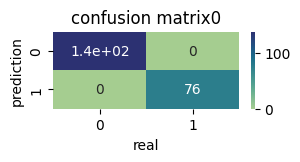

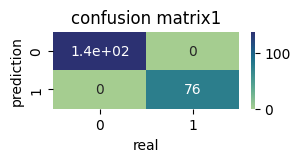

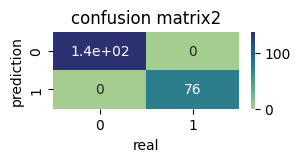

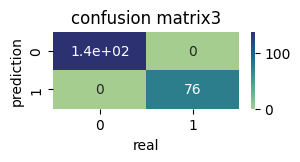

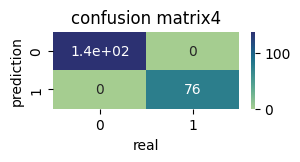

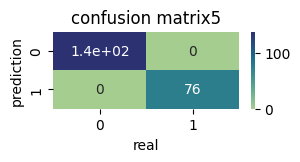

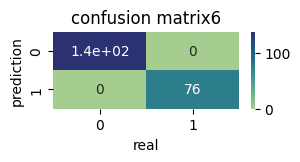

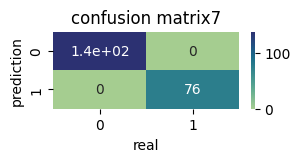

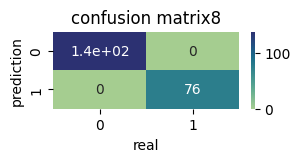

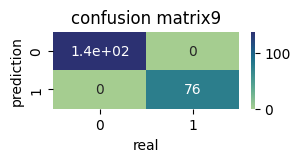

In [220]:
import seaborn as sn
for i in range(10):
 plt.figure(figsize=(3,1))
 sn.heatmap(cm[i], cmap="crest", annot=True, xticklabels=np.unique(y), yticklabels=np.unique(y))
 plt.ylabel("prediction")
 plt.xlabel("real")
 plt.title(f"confusion matrix{i}")
# plt.show()

 **DT my method**

In [221]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV


# پارامترهای جستجو
param_grid = {
    'max_depth': [2, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 4],
    'criterion': ['gini', 'entropy']
}

# مدل پایه
dt = DecisionTreeClassifier(random_state=42)

# StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# GridSearchCV
grid_search = GridSearchCV(dt, param_grid, cv=skf, scoring='accuracy', n_jobs=-1)
grid_search.fit(x, y)

# بهترین مدل
best_model = grid_search.best_estimator_

# لیست متریک‌ها
accuracies, precisions, recalls, f1_scores, cms = [], [], [], [], []

for train_idx, val_idx in skf.split(x, y):
    x_train, x_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]

    best_model.fit(x_train, y_train)
    y_pred = best_model.predict(x_test)

    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, average='weighted'))
    recalls.append(recall_score(y_test, y_pred, average='weighted'))
    f1_scores.append(f1_score(y_test, y_pred, average='weighted'))
    cms.append(confusion_matrix(y_test, y_pred))

print("Best Params:", grid_search.best_params_)
print(f"Accuracy: {np.mean(accuracies):.3f}")
print(f"Precision: {np.mean(precisions):.3f}")
print(f"Recall: {np.mean(recalls):.3f}")
print(f"F1 Score: {np.mean(f1_scores):.3f}")


Best Params: {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 1.000
Precision: 1.000
Recall: 1.000
F1 Score: 1.000


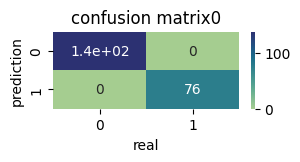

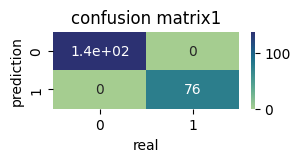

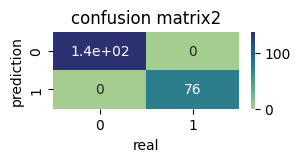

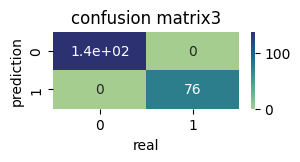

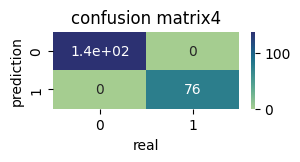

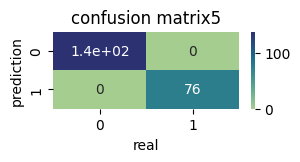

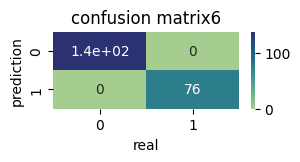

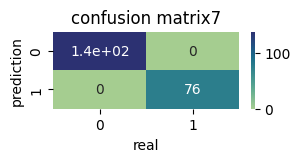

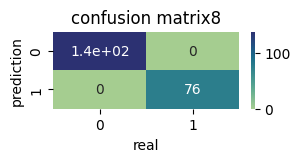

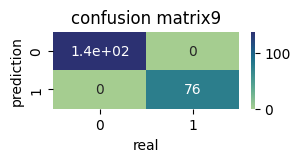

In [222]:
import seaborn as sn
for i in range(10):
 plt.figure(figsize=(3,1))
 sn.heatmap(cm[i], cmap="crest", annot=True, xticklabels=np.unique(y), yticklabels=np.unique(y))
 plt.ylabel("prediction")
 plt.xlabel("real")
 plt.title(f"confusion matrix{i}")
plt.show()

RandomForestClassifier

In [223]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# تعریف مدل پایه
rf_model = RandomForestClassifier(random_state=42)

# شبکه پارامترها برای جستجو
param_grid = {
    'n_estimators': [50, 200],
    'max_depth': [3, 7],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4]
}

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',   # می‌تونی به precision, recall هم تغییر بدی
    n_jobs=-1
)

# اجرای GridSearch
grid_search.fit(x, y)

# بهترین مدل
best_rf = grid_search.best_estimator_

print("Best Hyperparameters:", grid_search.best_params_)

# ارزیابی روی همان Stratified K-Fold برای دیدن میانگین متریک‌ها
accuracies, precisions, recalls, f1_scores, cms = [], [], [], [], []

for train_index, val_index in skf.split(x, y):
    x_train, x_val = x[train_index], x[val_index]
    y_train, y_val = y[train_index], y[val_index]

    best_rf.fit(x_train, y_train)
    y_pred = best_rf.predict(x_val)

    accuracies.append(accuracy_score(y_val, y_pred))
    precisions.append(precision_score(y_val, y_pred, average='weighted'))
    recalls.append(recall_score(y_val, y_pred, average='weighted'))
    f1_scores.append(f1_score(y_val, y_pred, average='weighted'))
    cms.append(confusion_matrix(y_val, y_pred))

print(f"Accuracy: {np.mean(accuracies):.3f}")
print(f"Precision: {np.mean(precisions):.3f}")
print(f"Recall: {np.mean(recalls):.3f}")
print(f"F1 Score: {np.mean(f1_scores):.3f}")


Best Hyperparameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Accuracy: 1.000
Precision: 1.000
Recall: 1.000
F1 Score: 1.000
